# Add Spot Masks to Existing Augmented Archive

This notebook converts the already generated local archive `data/augmented_spot_patches.h5`. It does not read raw detector files and it does not regenerate spot overlaps. For each sample it keeps the existing `image` and `spot_images` datasets, derives `spot_masks` from the nonzero support of each spot-intensity channel, and writes a converted HDF5 archive.


In [3]:
from pathlib import Path
import json

import h5py
try:
    import hdf5plugin  # noqa: F401 - registers optional HDF5 filters when available
except ImportError:
    hdf5plugin = None
import matplotlib.pyplot as plt
import numpy as np


def find_project_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "data" / "augmented_spot_patches.h5").exists():
            return candidate
        if (candidate / "train.py").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(
        "Could not find the project directory. Run this notebook from CodeMA/ "
        "or CodeMA/augment_data/."
    )


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
INPUT_FILE = DATA_DIR / "augmented_spot_patches.h5"
OUTPUT_FILE = DATA_DIR / "augmented_spot_patches_with_masks.h5"

# The original augmentation wrote exact zeros outside each spot mask.
MASK_THRESHOLD = 0.0
OVERWRITE_OUTPUT = True
COMPRESSION = "gzip"

print(f"Project dir : {PROJECT_DIR}")
print(f"Input file  : {INPUT_FILE}  exists={INPUT_FILE.exists()}")
print(f"Output file : {OUTPUT_FILE}")


Project dir : C:\Users\Natalie\CodeMA
Input file  : C:\Users\Natalie\CodeMA\data\augmented_spot_patches.h5  exists=True
Output file : C:\Users\Natalie\CodeMA\data\augmented_spot_patches_with_masks.h5


In [4]:
def sample_group_names(h5_file):
    with h5py.File(h5_file, "r") as f:
        return sorted(name for name, obj in f.items() if isinstance(obj, h5py.Group))


def derive_spot_masks(spot_images, threshold=MASK_THRESHOLD):
    spot_images = np.asarray(spot_images)
    if spot_images.ndim != 3 or spot_images.shape[0] != 2:
        raise ValueError(f"Expected spot_images shape (2, H, W), got {spot_images.shape}")
    return (spot_images > threshold).astype(np.uint8)


def copy_attrs(src, dst):
    for key, value in src.attrs.items():
        dst.attrs[key] = value


def create_dataset_like(group, name, data, compression=COMPRESSION):
    kwargs = {}
    if compression is not None and np.asarray(data).ndim > 0:
        kwargs["compression"] = compression
    group.create_dataset(name, data=data, **kwargs)


def robust_limits(array, lower=1, upper=99.8):
    values = np.asarray(array)[np.isfinite(array)]
    values = values[values > 0]
    if values.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.percentile(values, [lower, upper])
    if vmax <= vmin:
        vmin = 0.0
        vmax = float(values.max()) if values.max() > 0 else 1.0
    return float(vmin), float(vmax)


def target_overlay(spot_images):
    limits_0 = robust_limits(spot_images[0])
    limits_1 = robust_limits(spot_images[1])
    spot_0 = np.clip((spot_images[0] - limits_0[0]) / (limits_0[1] - limits_0[0]), 0.0, 1.0)
    spot_1 = np.clip((spot_images[1] - limits_1[0]) / (limits_1[1] - limits_1[0]), 0.0, 1.0)
    overlay = np.zeros((*spot_images.shape[1:], 3), dtype=np.float32)
    overlay[..., 0] = spot_0
    overlay[..., 1] = spot_1
    return overlay


def mask_overlay(spot_masks):
    overlay = np.zeros((*spot_masks.shape[1:], 3), dtype=np.float32)
    overlay[..., 0] = spot_masks[0]
    overlay[..., 1] = spot_masks[1]
    overlay[..., 2] = np.logical_and(spot_masks[0], spot_masks[1]).astype(np.float32)
    return overlay


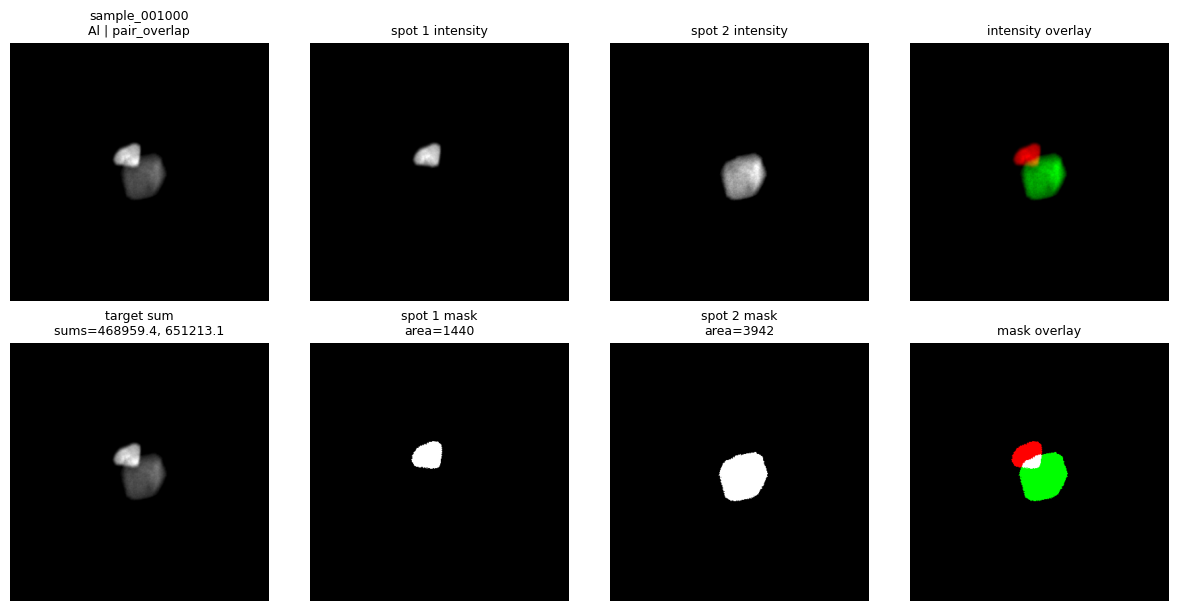

In [6]:
def preview_input_sample(path=INPUT_FILE, sample_index=0, threshold=MASK_THRESHOLD):
    path = Path(path)
    names = sample_group_names(path)
    if not names:
        raise ValueError(f"No sample groups found in {path}")

    name = names[int(sample_index) % len(names)]
    with h5py.File(path, "r") as f:
        group = f[name]
        image = group["image"][()]
        spot_images = group["spot_images"][()]
        spot_masks = group["spot_masks"][()] if "spot_masks" in group else derive_spot_masks(spot_images, threshold)
        dataset = group.attrs.get("dataset", "<missing>")
        kind = group.attrs.get("kind", "<missing>")

    spot_sums = spot_images.reshape(2, -1).sum(axis=1)
    mask_areas = spot_masks.reshape(2, -1).sum(axis=1)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)
    panels = [
        (image, f"{name}\n{dataset} | {kind}", "gray", *robust_limits(image)),
        (spot_images[0], "spot 1 intensity", "gray", *robust_limits(spot_images[0])),
        (spot_images[1], "spot 2 intensity", "gray", *robust_limits(spot_images[1])),
        (target_overlay(spot_images), "intensity overlay", None, None, None),
        (spot_images.sum(axis=0), f"target sum\nsums={spot_sums[0]:.1f}, {spot_sums[1]:.1f}", "gray", *robust_limits(spot_images.sum(axis=0))),
        (spot_masks[0], f"spot 1 mask\narea={int(mask_areas[0])}", "gray", 0, 1),
        (spot_masks[1], f"spot 2 mask\narea={int(mask_areas[1])}", "gray", 0, 1),
        (mask_overlay(spot_masks), "mask overlay", None, None, None),
    ]
    for axis, (data, title, cmap, vmin, vmax) in zip(axes.flat, panels):
        if cmap is None:
            axis.imshow(data)
        else:
            axis.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        axis.set_title(title, fontsize=9)
        axis.axis("off")
    plt.show()


preview_input_sample(sample_index=1000)


In [7]:
def convert_archive(input_file=INPUT_FILE, output_file=OUTPUT_FILE, threshold=MASK_THRESHOLD, overwrite=OVERWRITE_OUTPUT):
    input_file = Path(input_file)
    output_file = Path(output_file)
    if not input_file.exists():
        raise FileNotFoundError(f"Input archive not found: {input_file}")
    if output_file.exists() and not overwrite:
        raise FileExistsError(f"Output archive already exists: {output_file}")

    output_file.parent.mkdir(parents=True, exist_ok=True)
    tmp_file = output_file.with_name(f"{output_file.stem}.tmp{output_file.suffix}")
    if tmp_file.exists():
        tmp_file.unlink()

    sample_count = 0
    mask_pixel_count = np.zeros(2, dtype=np.int64)
    overlap_pixel_count = 0

    try:
        with h5py.File(input_file, "r") as src, h5py.File(tmp_file, "w") as dst:
            copy_attrs(src, dst)
            dst.attrs["target"] = "two_channel_spot_intensity_and_mask_separation"
            dst.attrs["derived_from"] = str(input_file)
            dst.attrs["spot_mask_source"] = f"spot_images > {float(threshold):g}"
            dst.attrs["spot_mask_dtype"] = "uint8"

            names = sorted(name for name, obj in src.items() if isinstance(obj, h5py.Group))
            for name in names:
                src_group = src[name]
                if "image" not in src_group or "spot_images" not in src_group:
                    raise ValueError(f"{name}: expected datasets image and spot_images")

                image = src_group["image"][()]
                spot_images = src_group["spot_images"][()]
                spot_masks = derive_spot_masks(spot_images, threshold)

                if spot_images.shape[1:] != image.shape:
                    raise ValueError(f"{name}: spot_images shape {spot_images.shape} does not match image {image.shape}")

                dst_group = dst.create_group(name)
                copy_attrs(src_group, dst_group)

                for dataset_name, dataset in src_group.items():
                    if dataset_name == "spot_masks":
                        continue
                    create_dataset_like(dst_group, dataset_name, dataset[()])
                create_dataset_like(dst_group, "spot_masks", spot_masks.astype(np.uint8, copy=False))

                mask_pixel_count += spot_masks.reshape(2, -1).sum(axis=1).astype(np.int64)
                overlap_pixel_count += int(np.logical_and(spot_masks[0], spot_masks[1]).sum())
                sample_count += 1

        tmp_file.replace(output_file)
    except Exception:
        if tmp_file.exists():
            tmp_file.unlink()
        raise

    print(f"Converted {sample_count} sample(s)")
    print(f"Wrote: {output_file}")
    print(f"Mask pixels spot 1 / spot 2: {mask_pixel_count[0]} / {mask_pixel_count[1]}")
    print(f"Overlapping mask pixels: {overlap_pixel_count}")
    return output_file


converted_file = convert_archive()


Converted 4468 sample(s)
Wrote: C:\Users\Natalie\CodeMA\data\augmented_spot_patches_with_masks.h5
Mask pixels spot 1 / spot 2: 17818917 / 22998154
Overlapping mask pixels: 5995958


In [8]:
def validate_archive(path=OUTPUT_FILE):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    problems = []
    with h5py.File(path, "r") as f:
        sample_names = sorted(name for name, obj in f.items() if isinstance(obj, h5py.Group))
        for name in sample_names:
            group = f[name]
            for required in ["image", "spot_images", "spot_masks"]:
                if required not in group:
                    problems.append(f"{name}: missing {required}")
            if problems:
                continue

            image = group["image"]
            spot_images = group["spot_images"]
            spot_masks = group["spot_masks"]
            if spot_images.shape[0] != 2:
                problems.append(f"{name}: spot_images should have 2 channels, got {spot_images.shape}")
            if spot_masks.shape != spot_images.shape:
                problems.append(f"{name}: spot_masks shape {spot_masks.shape} != spot_images shape {spot_images.shape}")
            if spot_images.shape[1:] != image.shape:
                problems.append(f"{name}: spot_images shape {spot_images.shape} does not align with image {image.shape}")
            mask_values = np.unique(spot_masks[()])
            if not set(mask_values.tolist()).issubset({0, 1}):
                problems.append(f"{name}: spot_masks are not binary, values={mask_values}")

    if problems:
        print("Validation problems:")
        for problem in problems[:20]:
            print(" -", problem)
        if len(problems) > 20:
            print(f" ... {len(problems) - 20} more")
    else:
        print(f"Archive looks OK: {len(sample_names)} sample(s) in {path}")


validate_archive(converted_file)


Archive looks OK: 4468 sample(s) in C:\Users\Natalie\CodeMA\data\augmented_spot_patches_with_masks.h5


File: C:\Users\Natalie\CodeMA\data\augmented_spot_patches_with_masks.h5
Samples: 4468
Attributes:
  augmentation: dataset-local unordered pairs; two random flip/rotation/overlap samples per pair
  datasets: ["Al", "Al_big_grains", "Al_small_grains", "Cu", "IN718_twins", "Iron", "Iron_deformed", "Ti7Al"]
  derived_from: C:\Users\Natalie\CodeMA\data\augmented_spot_patches.h5
  fixed_patch_shape: [384, 384]
  include_single_spot_variants: False
  overlap_range: [0.1, 0.9]
  patch_margin: 8
  random_pair_samples_per_pair: 2
  seed: 7
  source_catalog: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/confirmed_spots_merged.h5
  spot_mask_dtype: uint8
  spot_mask_source: spot_images > 0
  target: two_channel_spot_intensity_and_mask_separation
By dataset:
  Al: 1190
  Al_big_grains: 756
  Al_small_grains: 156
  Cu: 90
  IN718_twins: 992
  Iron: 992
  Iron_deformed: 20
  Ti7Al: 272
By kind:
  pair_overlap: 4468
Image shapes: {(384, 384): 4468}
Spot image shapes: {(2, 384,

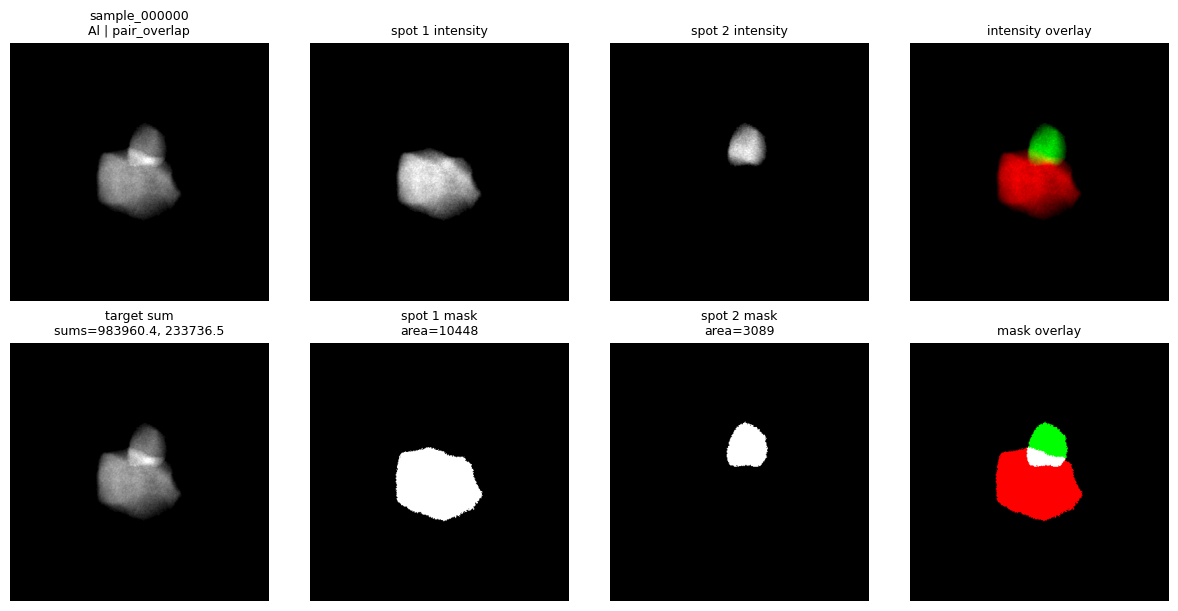

: 

In [ ]:
def summarize_archive(path=OUTPUT_FILE):
    path = Path(path)
    with h5py.File(path, "r") as f:
        sample_names = sorted(name for name, obj in f.items() if isinstance(obj, h5py.Group))
        print(f"File: {path}")
        print(f"Samples: {len(sample_names)}")
        print("Attributes:")
        for key, value in sorted(f.attrs.items()):
            print(f"  {key}: {value}")

        per_dataset = {}
        per_kind = {}
        image_shapes = {}
        spot_image_shapes = {}
        spot_mask_shapes = {}
        for name in sample_names:
            group = f[name]
            dataset = group.attrs.get("dataset", "<missing>")
            kind = group.attrs.get("kind", "<missing>")
            per_dataset[dataset] = per_dataset.get(dataset, 0) + 1
            per_kind[kind] = per_kind.get(kind, 0) + 1
            image_shapes[group["image"].shape] = image_shapes.get(group["image"].shape, 0) + 1
            spot_image_shapes[group["spot_images"].shape] = spot_image_shapes.get(group["spot_images"].shape, 0) + 1
            spot_mask_shapes[group["spot_masks"].shape] = spot_mask_shapes.get(group["spot_masks"].shape, 0) + 1

        print("By dataset:")
        for dataset, count in sorted(per_dataset.items()):
            print(f"  {dataset}: {count}")
        print("By kind:")
        for kind, count in sorted(per_kind.items()):
            print(f"  {kind}: {count}")
        print(f"Image shapes: {image_shapes}")
        print(f"Spot image shapes: {spot_image_shapes}")
        print(f"Spot mask shapes: {spot_mask_shapes}")


summarize_archive(converted_file)
preview_input_sample(path=converted_file, sample_index=0)
